# Strojenie parametrów augmentacji oświetleniowej

Celem eksperymentu jest określenie wpływu zakresu oraz prawdopodobieństwa losowej augmentacji jasności i kontrastu na skuteczność klasyfikacji znaków drogowych.

Jako model wykorzystano `ResNet50` z pretrenowanymi wagami ImageNet oraz strategią `WeightedRandomSampler`.

Porównywane konfiguracje różnią się wyłącznie parametrami augmentacji oświetleniowej.

Pozostałe elementy procesu uczenia pozostają niezmienione.

Etap ma charakter przesiewowy. Wszystkie konfiguracje są trenowane przez 5 epok przy zamrożonym backbone oraz 2 epoki fine-tuningu.

Podstawowym kryterium wyboru jest średnia wartość `Macro F1` dla wariantów kontrolowanego zaciemnienia `dark_1`, `dark_2` i `dark_3` na zbiorze walidacyjnym.

Zbiór `test_final` nie jest wykorzystywany na tym etapie.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "lighting_augmentation_tuning"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 5
FINE_TUNE_EPOCHS = 2
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True

CONFIGURATIONS = [
    {
        "name": "baseline",
        "brightness_range": None,
        "contrast_range": None,
        "probability": 0.0,
    },

    {
        "name": "lighting_current",
        "brightness_range": (
            0.5,
            1.3,
        ),
        "contrast_range": (
            0.8,
            1.2,
        ),
        "probability": 0.8,
    },

    {
        "name": "lighting_strong_dark",
        "brightness_range": (
            0.3,
            1.3,
        ),
        "contrast_range": (
            0.8,
            1.2,
        ),
        "probability": 0.8,
    },

    {
        "name": "lighting_balanced",
        "brightness_range": (
            0.5,
            1.5,
        ),
        "contrast_range": (
            0.7,
            1.3,
        ),
        "probability": 0.8,
    },

    {
        "name": "lighting_moderate",
        "brightness_range": (
            0.6,
            1.3,
        ),
        "contrast_range": (
            0.85,
            1.2,
        ),
        "probability": 0.8,
    },

    {
        "name": "lighting_high_probability",
        "brightness_range": (
            0.5,
            1.3,
        ),
        "contrast_range": (
            0.8,
            1.2,
        ),
        "probability": 1.0,
    },
]


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:

    print(
        configuration
    )

Konfiguracje:
{'name': 'baseline', 'brightness_range': None, 'contrast_range': None, 'probability': 0.0}
{'name': 'lighting_current', 'brightness_range': (0.5, 1.3), 'contrast_range': (0.8, 1.2), 'probability': 0.8}
{'name': 'lighting_strong_dark', 'brightness_range': (0.3, 1.3), 'contrast_range': (0.8, 1.2), 'probability': 0.8}
{'name': 'lighting_balanced', 'brightness_range': (0.5, 1.5), 'contrast_range': (0.7, 1.3), 'probability': 0.8}
{'name': 'lighting_moderate', 'brightness_range': (0.6, 1.3), 'contrast_range': (0.85, 1.2), 'probability': 0.8}
{'name': 'lighting_high_probability', 'brightness_range': (0.5, 1.3), 'contrast_range': (0.8, 1.2), 'probability': 1.0}


## 2. Manifesty i mapowanie klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje bazowe

Wszystkie konfiguracje wykorzystują identyczne operacje bazowe.

Augmentacja oświetleniowa jest jedynym zmienianym elementem eksperymentu.

In [4]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_train_transform(
    configuration,
):

    transform_list = [
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
        ),

        transforms.RandomRotation(
            10
        ),
    ]


    probability = (
        configuration[
            "probability"
        ]
    )


    if probability > 0:

        transform_list.append(
            RandomLightingAugmentation(
                brightness_range=(
                    configuration[
                        "brightness_range"
                    ]
                ),

                contrast_range=(
                    configuration[
                        "contrast_range"
                    ]
                ),

                probability=probability,
            )
        )


    transform_list.extend(
        [
            transforms.ToTensor(),
            normalization,
        ]
    )


    return transforms.Compose(
        transform_list
    )


def build_eval_transform():

    return transforms.Compose(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 4. Wizualizacja wyłącznie działania augmentacji oświetleniowej

Wizualizacja została oddzielona od pozostałych transformacji geometrycznych, aby ocena wpływu parametrów jasności i kontrastu nie była zaburzona przez losową rotację.

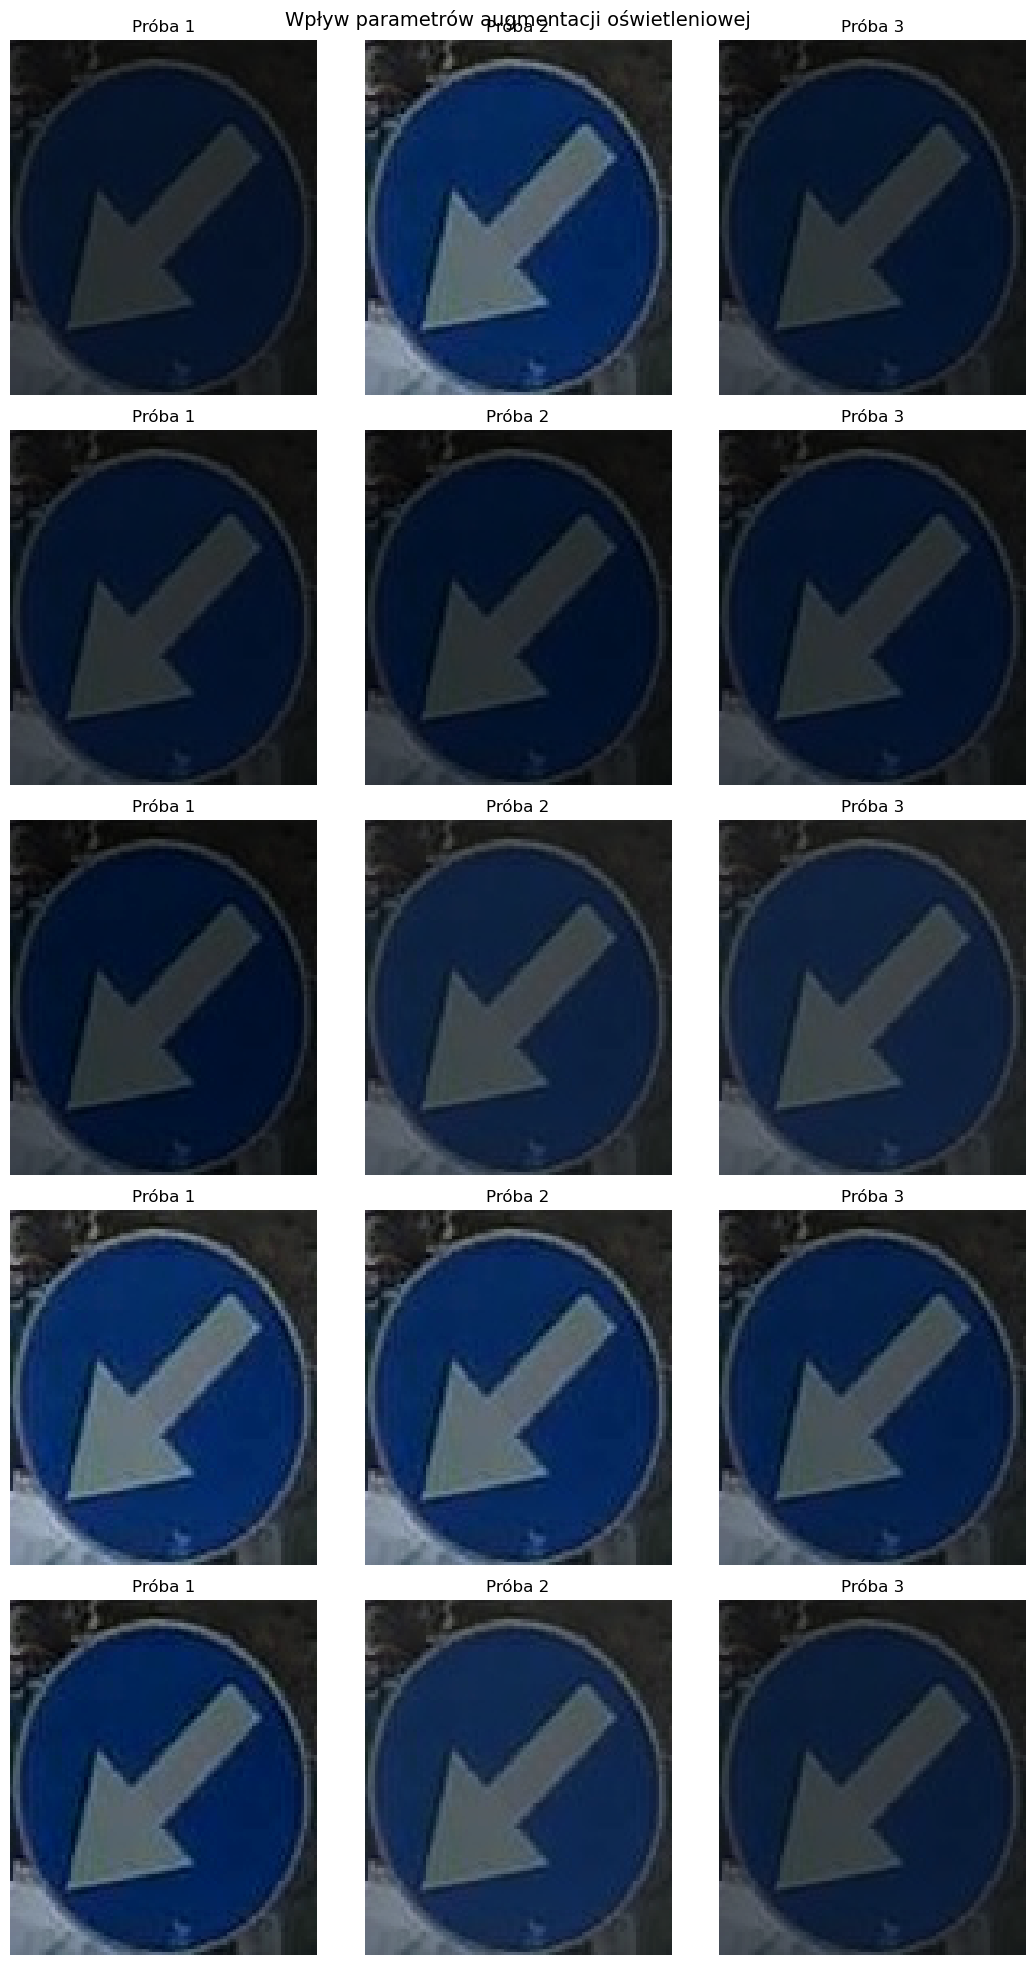

In [5]:
sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


lighting_configs = [
    configuration
    for configuration
    in CONFIGURATIONS
    if configuration[
        "probability"
    ] > 0
]


fig, axes = plt.subplots(
    len(lighting_configs),
    3,
    figsize=(11, 4 * len(lighting_configs)),
)


if len(lighting_configs) == 1:

    axes = np.array(
        [axes]
    )


for row_index, configuration in enumerate(
    lighting_configs
):

    augmentation = (
        RandomLightingAugmentation(
            brightness_range=(
                configuration[
                    "brightness_range"
                ]
            ),
            contrast_range=(
                configuration[
                    "contrast_range"
                ]
            ),
            probability=1.0,
        )
    )


    for col_index in range(3):

        augmented = augmentation(
            sample_image
        )


        axes[
            row_index,
            col_index
        ].imshow(
            augmented
        )


        axes[
            row_index,
            col_index
        ].set_title(
            f"Próba {col_index + 1}"
        )


        axes[
            row_index,
            col_index
        ].axis(
            "off"
        )


    axes[
        row_index,
        0
    ].set_ylabel(
        configuration[
            "name"
        ],
        fontsize=10,
    )


plt.suptitle(
    "Wpływ parametrów augmentacji "
    "oświetleniowej",
    fontsize=14,
)


plt.tight_layout()
plt.show()

## 5. Przygotowanie DataLoaderów

Zbiór treningowy wykorzystuje `WeightedRandomSampler`.

Zbiór walidacyjny jest deterministyczny i nie wykorzystuje losowej augmentacji.

In [6]:
def build_loaders(
    configuration,
):

    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=(
                build_train_transform(
                    configuration
                )
            ),
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=(
                build_eval_transform()
            ),
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 6. Przygotowanie modelu ResNet50

In [7]:
def create_model():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    return model

## 7. Funkcja treningu

Każda konfiguracja jest trenowana z wykorzystaniem identycznej procedury.

Jedynym zmiennym elementem jest zakres oraz prawdopodobieństwo augmentacji oświetleniowej.

In [8]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_loaders(
        configuration
    )


    model = create_model()


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"lighting_tuning_"
            f"{name}_"
            f"frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"lighting_tuning_"
            f"{name}_"
            f"finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration":
            configuration,

        "model":
            model,

        "validation_loader":
            validation_loader,

        "train_loader":
            train_loader,

        "frozen_history":
            frozen_history,

        "finetune_history":
            finetune_history,
    }

## 8. Trening screeningu

In [9]:
experiments = {}


for configuration in CONFIGURATIONS:

    result = train_configuration(
        configuration
    )


    experiments[
        configuration["name"]
    ] = result


print(
    "\nScreening zakończony."
)


Konfiguracja: baseline


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu:   0%|          | 0/2 [00:00<?, ?it/s]

Epoka 1/2:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/2:   0%|          | 0/445 [00:00<?, ?it/s]


Screening zakończony.


## 9. Skuteczność standardowa na zbiorze walidacyjnym

In [10]:
standard_results = []


for name, experiment in (
    experiments.items()
):

    y_true, y_pred, inference_time = (
        predict(
            experiment[
                "model"
            ],
            experiment[
                "validation_loader"
            ],
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    standard_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    standard_validation_df
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
5,lighting_high_probability,0.897293,0.887021,0.906383,0.891490,188.569368
0,baseline,0.895701,0.882199,0.903555,0.887332,189.783920
2,lighting_strong_dark,0.896099,0.885019,0.901706,0.887300,184.712270
3,lighting_balanced,0.894108,0.878729,0.900294,0.883717,176.462645
4,lighting_moderate,0.886545,0.875894,0.903371,0.883150,193.023137
1,lighting_current,0.893312,0.879873,0.897870,0.883069,199.688363


## 10. Funkcja oceny odporności na kontrolowane zaciemnienie

In [11]:
def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_eval_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 11. Ocena konfiguracji na kontrolowanym zaciemnieniu

In [12]:
dark_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]


    for variant in DARK_VARIANTS:

        print(
            f"{name} | {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model,
                variant,
            )
        )


        dark_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


dark_results_df = (
    pd.DataFrame(
        dark_results
    )
)


display(
    dark_results_df
)

baseline | dark_1
baseline | dark_2
baseline | dark_3
lighting_current | dark_1
lighting_current | dark_2
lighting_current | dark_3
lighting_strong_dark | dark_1
lighting_strong_dark | dark_2
lighting_strong_dark | dark_3
lighting_balanced | dark_1
lighting_balanced | dark_2
lighting_balanced | dark_3
lighting_moderate | dark_1
lighting_moderate | dark_2
lighting_moderate | dark_3
lighting_high_probability | dark_1
lighting_high_probability | dark_2
lighting_high_probability | dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,baseline,dark_1,0.7,2512,0.887739,0.875206,0.897674,0.878820,185.903501
1,baseline,dark_2,0.5,2512,0.872611,0.850638,0.855883,0.842603,187.700013
2,baseline,dark_3,0.3,2512,0.843153,0.819536,0.844606,0.816983,187.651410
3,lighting_current,dark_1,0.7,2512,0.892516,0.887103,0.909205,0.892842,188.498464
4,lighting_current,dark_2,0.5,2512,0.879379,0.865834,0.894207,0.870077,188.733974
5,lighting_current,dark_3,0.3,2512,0.856688,0.830254,0.864003,0.836083,190.614783
6,lighting_strong_dark,dark_1,0.7,2512,0.893710,0.887233,0.917723,0.897916,188.370296
7,lighting_strong_dark,dark_2,0.5,2512,0.883360,0.867149,0.899052,0.874780,184.998155
8,lighting_strong_dark,dark_3,0.3,2512,0.865844,0.846146,0.881838,0.854934,186.103928
9,lighting_balanced,dark_1,0.7,2512,0.890127,0.879255,0.906526,0.886378,184.486632


## 12. Zbiorcze porównanie odporności

Podstawowym kryterium jest średnia wartość `Macro F1` dla trzech poziomów zaciemnienia.

Dodatkowo analizowane są wyniki dla `dark_3`, czyli najsilniejszego kontrolowanego zaciemnienia.

In [13]:
dark_mean = (
    dark_results_df
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


dark3 = (
    dark_results_df[
        dark_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard = (
    standard_validation_df[
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


robustness_summary = (
    dark_mean
    .join(
        dark3
    )
    .join(
        standard
    )
)


robustness_summary[
    "f1_drop_to_dark3"
] = (
    robustness_summary[
        "standard_macro_f1"
    ]
    -
    robustness_summary[
        "dark3_macro_f1"
    ]
)


robustness_summary = (
    robustness_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    robustness_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_strong_dark,0.875877,0.880971,0.854934,0.887300,0.032366
lighting_high_probability,0.870568,0.880706,0.849628,0.891490,0.041862
lighting_balanced,0.867652,0.876725,0.847280,0.883717,0.036437
lighting_current,0.866334,0.876194,0.836083,0.883069,0.046986
lighting_moderate,0.859426,0.862925,0.834667,0.883150,0.048483
baseline,0.846135,0.867834,0.816983,0.887332,0.070349


## 13. Porównanie konfiguracji dla kolejnych poziomów zaciemnienia

configuration,baseline,lighting_balanced,lighting_current,lighting_high_probability,lighting_moderate,lighting_strong_dark
variant,,,,,,
dark_1,0.878820,0.886378,0.892842,0.892689,0.881128,0.897916
dark_2,0.842603,0.869297,0.870077,0.869388,0.862483,0.874780
dark_3,0.816983,0.847280,0.836083,0.849628,0.834667,0.854934


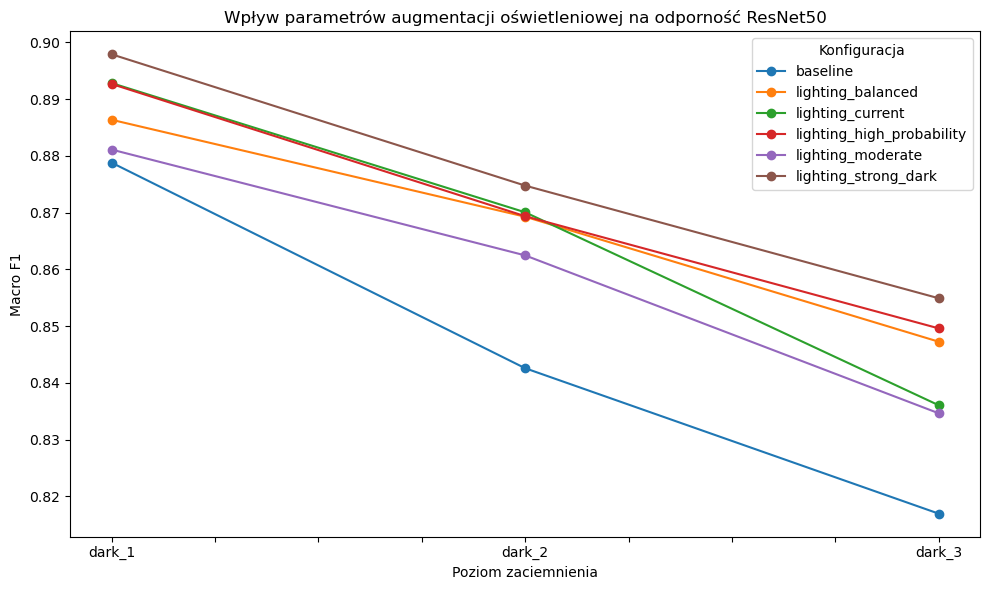

In [14]:
dark_plot = (
    dark_results_df
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        DARK_VARIANTS
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Wpływ parametrów augmentacji "
    "oświetleniowej na odporność ResNet50"
)

ax.set_xlabel(
    "Poziom zaciemnienia"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_lighting_parameter_tuning.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 14. Wybór najlepszej konfiguracji

Konfiguracja jest wybierana według najwyższej wartości średniego `Macro F1` dla `dark_1`, `dark_2` i `dark_3`.

Wynik dla obrazu oryginalnego oraz spadek `Macro F1` przy `dark_3` są traktowane jako kryteria uzupełniające.

In [15]:
best_configuration = (
    robustness_summary.index[0]
)


print(
    "Najlepsza konfiguracja:",
    best_configuration
)


display(
    robustness_summary.loc[
        [best_configuration]
    ]
)

Najlepsza konfiguracja: lighting_strong_dark


,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_strong_dark,0.875877,0.880971,0.854934,0.8873,0.032366


## 15. Porównanie z aktualną konfiguracją bazową

Aktualnym punktem odniesienia jest konfiguracja `Lighting Augmentation` stosowana w poprzednich eksperymentach:

- jasność: 0.5–1.3,
- kontrast: 0.8–1.2,
- prawdopodobieństwo: 0.8.


In [16]:
current_configuration = "lighting_current"


if (
    current_configuration
    in robustness_summary.index
):

    comparison = (
        robustness_summary.loc[
            [
                current_configuration,
                best_configuration,
            ]
        ]
        .copy()
    )


    display(
        comparison
    )

else:

    print(
        "Nie znaleziono konfiguracji "
        "lighting_current."
    )

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_current,0.866334,0.876194,0.836083,0.883069,0.046986
lighting_strong_dark,0.875877,0.880971,0.854934,0.887300,0.032366


## 16. Zapis wyników screeningu

In [17]:
standard_validation_df.to_csv(
    METRICS_DIR
    / "lighting_tuning_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


dark_results_df.to_csv(
    METRICS_DIR
    / "lighting_tuning_dark_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


robustness_summary.to_csv(
    METRICS_DIR
    / "lighting_tuning_summary.csv",
    encoding="utf-8-sig",
)


selection = {
    "experiment":
        "lighting_augmentation_tuning",

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "selection_metric":
        "mean_dark_macro_f1",

    "best_configuration":
        best_configuration,

    "results":
        robustness_summary
        .reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "lighting_tuning_selection.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "lighting_augmentation_tuning",
  "frozen_epochs": 5,
  "fine_tune_epochs": 2,
  "selection_metric": "mean_dark_macro_f1",
  "best_configuration": "lighting_strong_dark",
  "results": [
    {
      "configuration": "lighting_strong_dark",
      "mean_dark_macro_f1": 0.875876538898519,
      "mean_dark_accuracy": 0.8809713375796179,
      "dark3_macro_f1": 0.8549339366813804,
      "standard_macro_f1": 0.8872997734704953,
      "f1_drop_to_dark3": 0.032365836789114866
    },
    {
      "configuration": "lighting_high_probability",
      "mean_dark_macro_f1": 0.870568004387525,
      "mean_dark_accuracy": 0.8807059447983016,
      "dark3_macro_f1": 0.8496275184934403,
      "standard_macro_f1": 0.8914898158957973,
      "f1_drop_to_dark3": 0.04186229740235703
    },
    {
      "configuration": "lighting_balanced",
      "mean_dark_macro_f1": 0.8676516567686822,
      "mean_dark_accuracy": 0.8767250530785562,
      "dark3_macro_f1": 0.847279578766398,
      "standard_m